# Preprocessing external datasets: Absinta et al. (2021) and Lerma-Martin et al. (2024)

In [ ]:
import os
import gzip
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from scipy import sparse

np.random.seed(42)

Source data downloaded from GEO (accession GSE180759) and EGA (EGAC50000000231)

# Load and preprocess data

Load raw counts

In [ ]:
def load_csv_to_sparse(filepath):
    """
    Load compressed CSV dense matrix to sparse matrix
    """
    row_indices = []
    col_indices = []
    data = []
    row_names = []

    with gzip.open(filepath, 'rt') as f:
        col_names = f.readline().strip().split(',')

        row_idx = 0
        for line in f:
            row = line.strip().split(',')
            row_name = row[0]
            row_names.append(row_name)

            values = [float(x) if x else 0.0 for x in row[1:]]
            for col_idx, val in enumerate(values):
                if val > 0.0:
                    row_indices.append(row_idx)
                    col_indices.append(col_idx)
                    data.append(val)

            row_idx += 1

    mat = sparse.csr_matrix(
        (data, (row_indices, col_indices)),
        shape=(len(row_names), len(col_names)),
        dtype=float
    )

    return mat, row_names, col_names

In [76]:
counts, var_names, obs_names = load_csv_to_sparse("../data/processed/external/lesion_rims/source/absinta/GSE180759_expression_matrix.csv.gz")
counts = counts.transpose()
obs = pd.read_csv(
    "../data/processed/external/lesion_rims/source/absinta/GSE180759_annotation.txt.gz",
    sep="\t",
    header=0,
    index_col=0,
).rename(
    columns={
        "NBB_case": "donor_id",
        "cell_type": "celltype",
        "pathology": "lesion_type",
    }
)
obs["lesion_type"] = obs["lesion_type"].replace({
    "chronic_active_MS_lesion_edge": "CA",
    "MS_periplaque_white_matter": "NAWM",
    "chronic_inactive_MS_lesion_edge": "CI",
    "control_white_matter": "Ctrl",
    "MS_lesion_core": "Core",
})
obs["donor_id"] = obs["donor_id"].replace({"11_69": "11_069"})
obs["sample_id"] = obs["donor_id"] + "_" + obs["lesion_type"]
obs["study"] = "Absinta et al. 2021"
obs.index.name = None
donor_metadata = pd.read_csv("../data/processed/external/lesion_rims/source/absinta/donor_metadata.csv", sep=",", header=0, index_col=None)
obs = pd.merge(obs, donor_metadata, left_on="donor_id", right_on="donor_id", how="left").set_index(obs.index)
obs = obs[["study", "sample_id", "lesion_type", "donor_id", "age", "sex", "diagnosis", "duration_y", "cause_death", "pmi_hrs", "celltype"]]
var = pd.DataFrame(index=var_names)
adata_a = ad.AnnData(X=counts, obs=obs, var=var)

In [78]:
adata_lm = sc.read_h5ad("../data/processed/external/lerma-martin/source/sn_atlas.h5ad")
adata_lm.obs = adata_lm.obs.rename(
    columns={
        "patient_id": "donor_id",
        "condition": "diagnosis",
    }
)
adata_lm.obs["study"] = "Lerma-Martin et al. 2024"
adata_lm.obs["diagnosis"] = adata_lm.obs["diagnosis"].replace({"MS": "SPMS"})
adata_lm.obs = adata_lm.obs[["study", "sample_id", "lesion_type", "donor_id", "age", "sex", "diagnosis", "duration_y", "cause_death", "pmi_hrs", "celltype"]]

In [79]:
adata = ad.concat([adata_a, adata_lm], join="outer")

In [80]:
adata

AnnData object with n_obs × n_vars = 170226 × 34754
    obs: 'study', 'sample_id', 'lesion_type', 'donor_id', 'age', 'sex', 'diagnosis', 'duration_y', 'cause_death', 'pmi_hrs', 'celltype'
    obsm: 'X_pca', 'X_umap'

Standardise gene names across datasets and aggregate counts for alias genes in original count matrix

In [82]:
translation = pd.read_csv("../data/processed/external/lesion_rims/source/lesion_rims_genes_translation.tsv", sep="\t", header=0, index_col="original_gene_symbol")
translation.index.name = None

adata = adata[:, translation.index].copy()
adata.var = translation.copy()

grouped = translation.groupby('ensembl_id')
n_original_genes = adata.n_vars
unique_ensembl_ids = translation['ensembl_id'].unique()
n_unique_genes = len(unique_ensembl_ids)
ensembl_to_new_idx = {ensembl_id: i for i, ensembl_id in enumerate(unique_ensembl_ids)}

row_indices = []
col_indices = []
data = []

for old_idx, (ensembl_id, gene_symbol) in enumerate(zip(translation['ensembl_id'], translation['gene_symbol'])):
    new_idx = ensembl_to_new_idx[ensembl_id]
    row_indices.append(new_idx)
    col_indices.append(old_idx)
    data.append(1.0)

aggregation_matrix = sparse.csr_matrix(
    (data, (row_indices, col_indices)), 
    shape=(n_unique_genes, n_original_genes)
)

X_aggregated = (aggregation_matrix @ adata.X.T).T

new_var = pd.DataFrame(index=unique_ensembl_ids)
new_var['ensembl_id'] = unique_ensembl_ids
new_var['gene_symbol'] = [grouped.get_group(ensembl_id)['gene_symbol'].iloc[0] 
                          for ensembl_id in unique_ensembl_ids]
new_var['gene_type'] = [grouped.get_group(ensembl_id)['gene_type'].iloc[0]
                        for ensembl_id in unique_ensembl_ids]
new_var.index = new_var['gene_symbol']
new_var.index.name = None

adata = ad.AnnData(
    X=X_aggregated,
    obs=adata.obs.copy(),
    var=new_var
)
adata.var_names_make_unique()

sc.pp.filter_genes(adata, min_cells=1)

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [84]:
# Store raw counts for use with starCAT
adata.raw = adata
adata

AnnData object with n_obs × n_vars = 170226 × 20521
    obs: 'study', 'sample_id', 'lesion_type', 'donor_id', 'age', 'sex', 'diagnosis', 'duration_y', 'cause_death', 'pmi_hrs', 'celltype'
    var: 'ensembl_id', 'gene_symbol', 'gene_type', 'n_cells'

# Normalise, find variable features across datasets and integrate

Load cell cycle genes (plain text files with one gene symbol per line containing the genes from Seurat `cc.genes$g2m.genes` and `cc.genes$s.genes`)

In [ ]:
with open("../data/ref/genes/g2m_genes.txt") as f:
    g2m_genes = f.read().splitlines()
    g2m_genes = [gene for gene in g2m_genes if gene in adata.var_names]

with open("../data/ref/genes/s_genes.txt") as f:
    s_genes = f.read().splitlines()
    s_genes = [gene for gene in s_genes if gene in adata.var_names]

In [86]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key="sample_id")
# Exclude mitochondrial and ribosomal genes from highly variable features
mito_genes = adata.var_names.str.startswith("MT-")
ribo_genes = adata.var_names.str.startswith(("RPS", "RPL"))
exclude_genes = mito_genes | ribo_genes
adata.var.loc[exclude_genes, "highly_variable"] = False
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(adata, keys=["S_score", "G2M_score"], n_jobs=16)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
sc.external.pp.harmony_integrate(adata, key=["sample_id", "study"], max_iter_harmony=50)

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
2025-10-08 01:29:10,760 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-08 01:29:22,018 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-08 01:29:22,698 - harmonypy - INFO - Iteration 1 of 50
2025-10-08 01:30:16,674 - harmonypy - INFO - Iteration 2 of 50
2025-10-08 01:31:09,673 - harmonypy - INFO - Iteration 3 of 50
2025-10-08 01:32:03,714 - harmonypy - INFO - Converged after 3 iterations


In [87]:
sc.pp.neighbors(adata, transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="X_pca_harmony")
sc.tl.umap(adata)

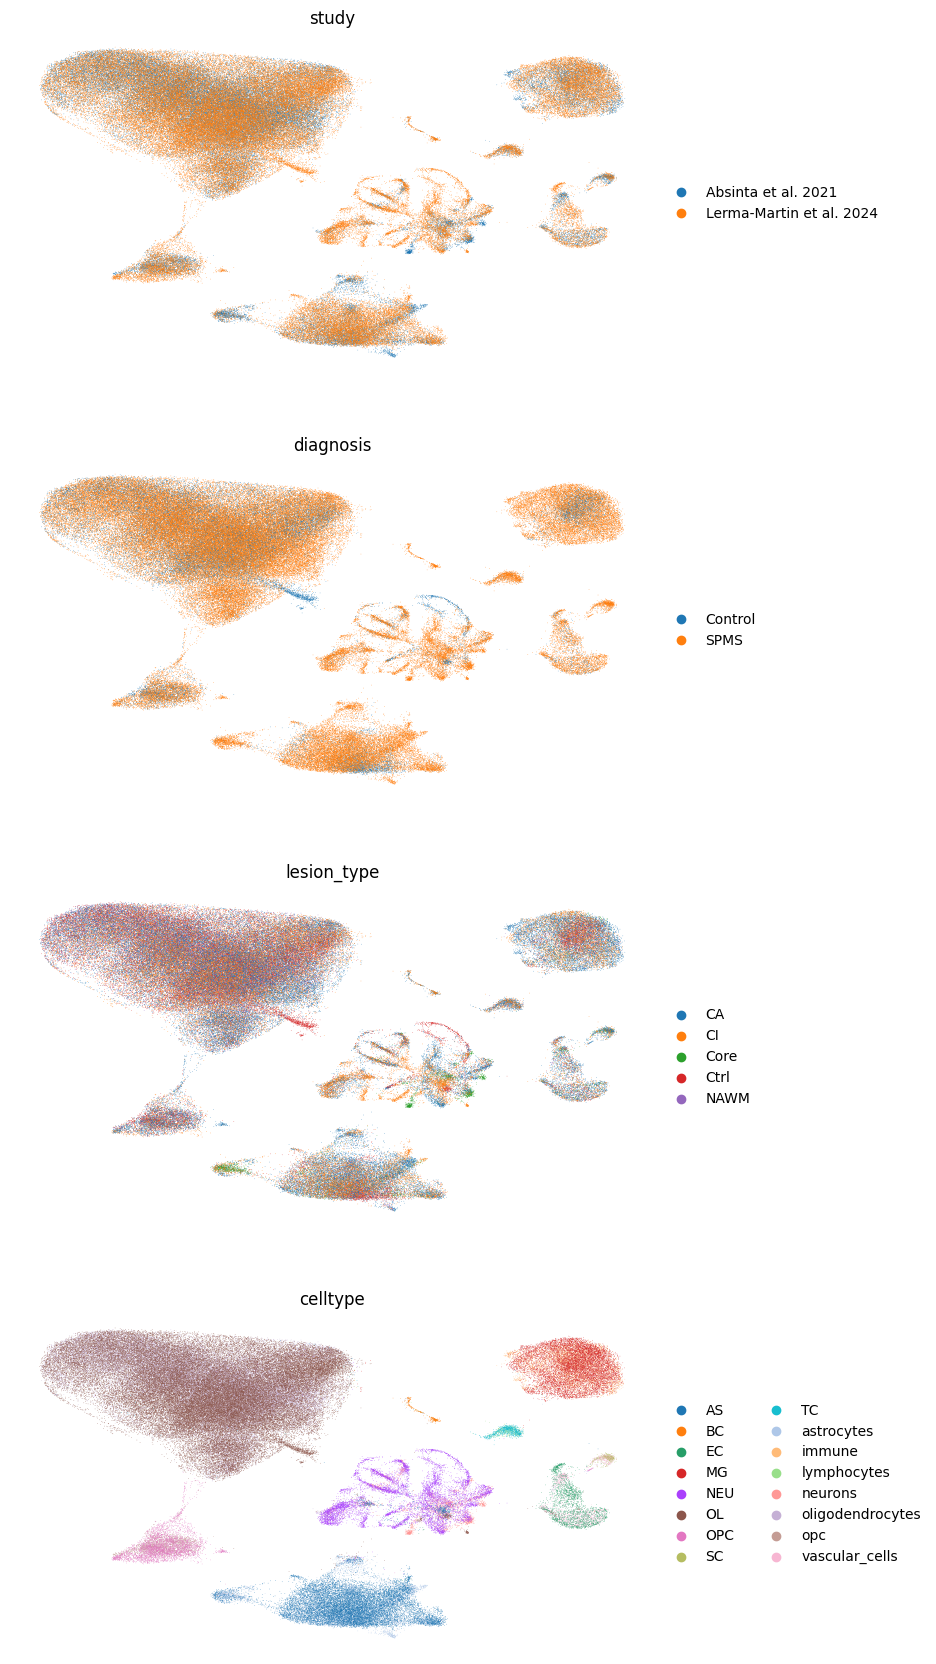

In [88]:
sc.pl.umap(adata, color=["study", "diagnosis", "lesion_type", "celltype"], wspace=0.4, frameon=False, ncols=1)

In [ ]:
# Save processed data
os.makedirs("../data/processed/external/lesion_rims/annotated", exist_ok=True)
adata.write_h5ad("../data/processed/external/lesion_rims/annotated/lesion_rims_full.h5ad")

Filter to lymphocytes only

In [98]:
adata = adata[adata.obs["celltype"].isin(["BC", "TC", "lymphocytes"]), :].copy()

In [100]:
sc.pp.neighbors(adata, transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="X_pca_harmony")
sc.tl.umap(adata)

In [102]:
# Save processed data
adata.write_h5ad("../data/processed/external/lesion_rims/annotated/lesion_rims_lymphocytes.h5ad")